# Minimum Wage and Employment: A Difference-in-Differences Analysis

## Research Question

Did New Jersey's 1992 minimum-wage increase affect employment in the fast-food industry?

## Research Design

- **Treatment group:** New Jersey
- **Control group:** Eastern Pennsylvania
- **Pre-treatment period:** February 1992
- **Post-treatment period:** November 1992
- **Policy change:** New Jersey's minimum wage increased from \$4.25 to \$5.05 per hour, while Pennsylvania's minimum wage remained unchanged.

## Methodology

This project uses a Difference-in-Differences (DiD) framework to estimate the relative employment effect of New Jersey's 1992 minimum-wage increase using fast-food restaurant data from New Jersey and eastern Pennsylvania.

The analysis includes:

- Exploratory data analysis
- Difference-in-Differences estimation
- Restaurant-clustered standard errors
- Covariate-adjusted regression
- Balanced-panel analysis
- Restaurant fixed effects
- First-difference estimation
- Exploratory heterogeneous treatment effects
- Robustness and sensitivity checks

## Data Source

This project uses a reorganized version of the dataset from Card and Krueger's study of the 1992 New Jersey minimum-wage increase.

The original study surveyed 410 fast-food restaurants in New Jersey and eastern Pennsylvania before and after New Jersey increased its minimum wage from **\$4.25 to \$5.05 per hour** in April 1992. Pennsylvania, where the minimum wage remained unchanged during the study period, serves as the comparison group.

The dataset used in this analysis is a long-format replication dataset derived from the original Card and Krueger data. Each restaurant appears in two survey periods, producing 820 observations in total.

**Original study:**  
Card, D., & Krueger, A. B. (1994). *Minimum Wages and Employment: A Case Study of the Fast-Food Industry in New Jersey and Pennsylvania*. American Economic Review, 84(4), 772–793.

**Original data archive:**  
David Card, UC Berkeley — New Jersey Minimum Wage Data

**Replication dataset used in this notebook:**  
`njmin3.csv`, publicly available through the Card–Krueger replication repository.

### Key Variables

- `nj`: New Jersey indicator (1 = New Jersey, 0 = Pennsylvania)
- `d`: Post-treatment indicator (1 = after the minimum-wage increase, 0 = before)
- `d_nj`: Treatment × post-period interaction
- `fte`: Full-time-equivalent employment
- `demp`: Change in FTE employment between survey periods
- `bk`, `kfc`, `roys`, `wendys`: Restaurant-chain indicators
- `co_owned`: Company-owned restaurant indicator
- `centralj`, `southj`, `pa1`, `pa2`: Geographic indicators

## 1. Data and Setup

The analysis uses a long-format version of the Card and Krueger dataset containing 820 observations from 410 fast-food restaurants across two survey periods. This section loads the required libraries, imports the dataset, and examines its basic structure and data quality.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

print("Environment ready.")

Environment ready.


In [32]:
url = "https://raw.githubusercontent.com/AnthonyPuggs/CardKrueger1994Replication/main/njmin3.csv"

df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()

Shape: (820, 14)


,nj,d,d_nj,fte,bk,kfc,roys,wendys,co_owned,centralj,southj,pa1,pa2,demp
0,1,0,0,15.00,1,0,0,0,0,1,0,0,0,12.00
1,1,0,0,15.00,1,0,0,0,0,1,0,0,0,6.50
2,1,0,0,24.00,0,0,1,0,0,1,0,0,0,-1.00
3,1,0,0,19.25,0,0,1,0,1,0,0,0,0,2.25
4,1,0,0,21.50,1,0,0,0,0,0,0,0,0,13.00


### 1.1 Data Quality Checks

Before estimation, the dataset is examined for variable types, missing observations, and duplicate records. Missing employment observations are retained at this stage and handled explicitly when constructing the estimation samples used in subsequent analyses.

In [33]:
# Basic data quality checks

print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (820, 14)

Data types:
nj            int64
d             int64
d_nj          int64
fte         float64
bk            int64
kfc           int64
roys          int64
wendys        int64
co_owned      int64
centralj      int64
southj        int64
pa1           int64
pa2           int64
demp        float64
dtype: object

Missing values:
nj           0
d            0
d_nj         0
fte         26
bk           0
kfc          0
roys         0
wendys       0
co_owned     0
centralj     0
southj       0
pa1          0
pa2          0
demp        52
dtype: int64

Duplicate rows: 13


### 1.2 Sample Composition and Employment Summary

The sample contains 331 New Jersey restaurants and 79 Pennsylvania restaurants observed in both survey periods. This section examines the treatment-control composition, summarizes full-time-equivalent (FTE) employment, and evaluates missing employment observations before constructing the estimation sample.

In [34]:
# Check treatment and time groups

print("New Jersey observations:")
print(df["nj"].value_counts())

print("\nSurvey periods:")
print(df["d"].value_counts())

print("\nTreatment × Time:")
print(pd.crosstab(df["nj"], df["d"]))

New Jersey observations:
nj
1    662
0    158
Name: count, dtype: int64

Survey periods:
d
0    410
1    410
Name: count, dtype: int64

Treatment × Time:
d     0    1
nj          
0    79   79
1   331  331


In [35]:
# Summary statistics for employment

df["fte"].describe()

,fte
count,794.000000
mean,21.026511
std,9.422746
min,0.000000
25%,14.500000
50%,20.000000
75%,25.500000
max,85.000000


In [36]:
# Inspect missing employment observations

missing_fte = df[df["fte"].isna()]

print("Number of missing fte:", len(missing_fte))

print("\nMissing fte by state:")
print(missing_fte["nj"].value_counts())

print("\nMissing fte by survey period:")
print(missing_fte["d"].value_counts())

print("\nMissing fte by treatment × time:")
print(pd.crosstab(missing_fte["nj"], missing_fte["d"]))

print("\nRows with missing fte:")
display(missing_fte)

Number of missing fte: 26

Missing fte by state:
nj
1    22
0     4
Name: count, dtype: int64

Missing fte by survey period:
d
1    14
0    12
Name: count, dtype: int64

Missing fte by treatment × time:
d    0   1
nj        
0    2   2
1   10  12

Rows with missing fte:


,nj,d,d_nj,fte,bk,kfc,roys,wendys,co_owned,centralj,southj,pa1,pa2,demp
7,1,0,0,NaN,1,0,0,0,0,0,0,0,0,NaN
38,1,0,0,NaN,0,0,0,1,0,1,0,0,0,NaN
86,1,0,0,NaN,0,0,1,0,1,0,0,0,0,NaN
95,1,0,0,NaN,0,0,0,1,0,1,0,0,0,NaN
116,1,0,0,NaN,1,0,0,0,1,0,0,0,0,NaN
129,1,0,0,NaN,0,0,0,1,0,0,0,0,0,NaN
132,1,0,0,NaN,1,0,0,0,0,1,0,0,0,NaN
193,1,0,0,NaN,1,0,0,0,0,0,0,0,0,NaN
290,1,0,0,NaN,0,1,0,0,0,0,1,0,0,NaN
302,1,0,0,NaN,1,0,0,0,0,0,0,0,0,NaN


In [37]:
# Examine missingness across variables

print("Missing values by variable:")
print(df.isna().sum())

print("\nMissing fte and demp:")
print(df.loc[df["fte"].isna(), ["nj", "d", "fte", "demp"]])

print("\nMissing fte by state and period:")
print(
    df[df["fte"].isna()]
    .groupby(["nj", "d"])
    .size()
)

Missing values by variable:
nj           0
d            0
d_nj         0
fte         26
bk           0
kfc          0
roys         0
wendys       0
co_owned     0
centralj     0
southj       0
pa1          0
pa2          0
demp        52
dtype: int64

Missing fte and demp:
     nj  d  fte  demp
7     1  0  NaN   NaN
38    1  0  NaN   NaN
86    1  0  NaN   NaN
95    1  0  NaN   NaN
116   1  0  NaN   NaN
129   1  0  NaN   NaN
132   1  0  NaN   NaN
193   1  0  NaN   NaN
290   1  0  NaN   NaN
302   1  0  NaN   NaN
360   1  1  NaN   NaN
364   1  1  NaN   NaN
370   1  1  NaN   NaN
390   1  1  NaN   NaN
449   1  1  NaN   NaN
494   1  1  NaN   NaN
555   1  1  NaN   NaN
566   1  1  NaN   NaN
588   1  1  NaN   NaN
596   1  1  NaN   NaN
615   1  1  NaN   NaN
616   1  1  NaN   NaN
695   0  0  NaN   NaN
714   0  0  NaN   NaN
746   0  1  NaN   NaN
810   0  1  NaN   NaN

Missing fte by state and period:
nj  d
0   0     2
    1     2
1   0    10
    1    12
dtype: int64


### 1.3 Estimation Sample

Observations with missing FTE employment are excluded from analyses that require the employment outcome. This produces an estimation sample of 794 restaurant-period observations. The treatment and control groups remain represented in both survey periods after this restriction.

In [38]:
# Create analysis dataset

df_analysis = df.dropna(subset=["fte"]).copy()

print("Original observations:", len(df))
print("Analysis observations:", len(df_analysis))
print("Dropped observations:", len(df) - len(df_analysis))

print("\nTreatment × Time after cleaning:")
print(pd.crosstab(df_analysis["nj"], df_analysis["d"]))

Original observations: 820
Analysis observations: 794
Dropped observations: 26

Treatment × Time after cleaning:
d     0    1
nj          
0    77   77
1   321  319


## 2. Descriptive Evidence and Difference-in-Differences

Before estimating the regression model, mean FTE employment is compared across states and survey periods. Pennsylvania's mean employment declined after the policy change, while New Jersey's mean employment increased slightly. The resulting difference in these changes provides the raw Difference-in-Differences estimate.

In [39]:
# Mean employment by state and survey period

group_means = (
    df_analysis
    .groupby(["nj", "d"])["fte"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

group_means["state"] = group_means["nj"].map({
    0: "Pennsylvania",
    1: "New Jersey"
})

group_means["period"] = group_means["d"].map({
    0: "Before",
    1: "After"
})

group_means[["state", "period", "mean", "std", "count"]]

,state,period,mean,std,count
0,Pennsylvania,Before,23.331169,11.856283,77
1,Pennsylvania,After,21.165584,8.276732,77
2,New Jersey,Before,20.439408,9.106239,321
3,New Jersey,After,21.027429,9.293024,319


In [40]:
# Calculate employment changes within each state

before_after = (
    df_analysis
    .groupby(["nj", "d"])["fte"]
    .mean()
    .unstack()
)

before_after.columns = ["Before", "After"]
before_after["Change"] = before_after["After"] - before_after["Before"]

before_after.index = ["Pennsylvania", "New Jersey"]

before_after

,Before,After,Change
Pennsylvania,23.331169,21.165584,-2.165584
New Jersey,20.439408,21.027429,0.588021


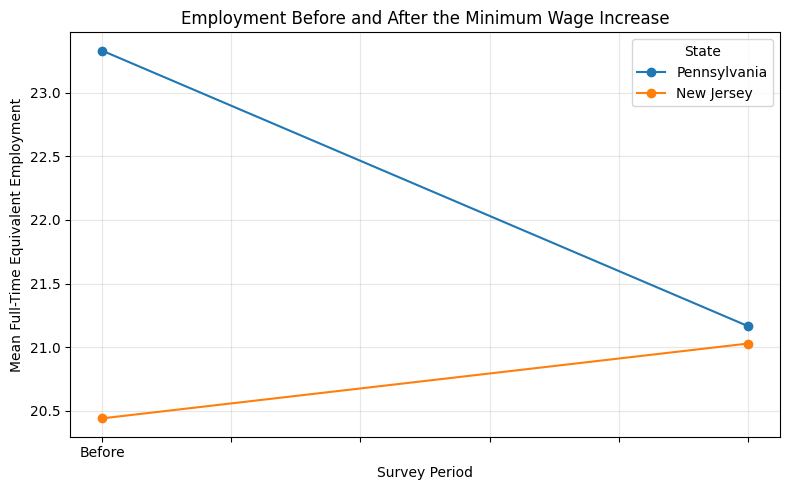

In [41]:
# Plot mean employment before and after the minimum wage increase

plot_data = before_after[["Before", "After"]].copy()

ax = plot_data.T.plot(
    marker="o",
    figsize=(8, 5)
)

ax.set_xlabel("Survey Period")
ax.set_ylabel("Mean Full-Time Equivalent Employment")
ax.set_title("Employment Before and After the Minimum Wage Increase")
ax.legend(title="State")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
# Difference-in-Differences estimation

pa_change = (
    before_after.loc["Pennsylvania", "After"]
    - before_after.loc["Pennsylvania", "Before"]
)

nj_change = (
    before_after.loc["New Jersey", "After"]
    - before_after.loc["New Jersey", "Before"]
)

did_estimate = nj_change - pa_change

print(f"Pennsylvania change: {pa_change:.3f}")
print(f"New Jersey change: {nj_change:.3f}")
print(f"Difference-in-Differences estimate: {did_estimate:.3f}")

Pennsylvania change: -2.166
New Jersey change: 0.588
Difference-in-Differences estimate: 2.754


In [43]:
# Difference-in-Differences regression

did_model = smf.ols(
    "fte ~ nj + d + nj:d",
    data=df_analysis
).fit()

print(did_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.964
Date:                Fri, 04 Sep 2026   Prob (F-statistic):              0.118
Time:                        06:54:21   Log-Likelihood:                -2904.2
No. Observations:                 794   AIC:                             5816.
Df Residuals:                     790   BIC:                             5835.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.3312      1.072     21.767      0.0

In [44]:
# Inspect dataset structure for panel identification

print("Dataset columns:")
print(df_analysis.columns.tolist())

print("\nFirst 20 observations:")
display(df_analysis.head(20))

print("\nIndex information:")
print(df_analysis.index[:20].tolist())

Dataset columns:
['nj', 'd', 'd_nj', 'fte', 'bk', 'kfc', 'roys', 'wendys', 'co_owned', 'centralj', 'southj', 'pa1', 'pa2', 'demp']

First 20 observations:


,nj,d,d_nj,fte,bk,kfc,roys,wendys,co_owned,centralj,southj,pa1,pa2,demp
0,1,0,0,15.00,1,0,0,0,0,1,0,0,0,12.00
1,1,0,0,15.00,1,0,0,0,0,1,0,0,0,6.50
2,1,0,0,24.00,0,0,1,0,0,1,0,0,0,-1.00
3,1,0,0,19.25,0,0,1,0,1,0,0,0,0,2.25
4,1,0,0,21.50,1,0,0,0,0,0,0,0,0,13.00
5,1,0,0,9.50,0,1,0,0,0,0,0,0,0,1.00
6,1,0,0,44.00,0,0,0,1,0,0,0,0,0,-27.50
8,1,0,0,21.00,1,0,0,0,0,0,0,0,0,17.00
9,1,0,0,28.00,0,0,0,1,0,0,1,0,0,8.00
10,1,0,0,10.00,0,0,0,1,0,0,1,0,0,6.00



Index information:
[0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


In [45]:
# Verify restaurant pairing within each state

nj_before = df[(df["nj"] == 1) & (df["d"] == 0)].reset_index(drop=True)
nj_after  = df[(df["nj"] == 1) & (df["d"] == 1)].reset_index(drop=True)

pa_before = df[(df["nj"] == 0) & (df["d"] == 0)].reset_index(drop=True)
pa_after  = df[(df["nj"] == 0) & (df["d"] == 1)].reset_index(drop=True)

print("NJ:", len(nj_before), len(nj_after))
print("PA:", len(pa_before), len(pa_after))

static_vars = [
    "nj", "bk", "kfc", "roys", "wendys",
    "co_owned", "centralj", "southj", "pa1", "pa2"
]

print("\nNJ characteristic matches:")
for var in static_vars:
    print(
        f"{var}: "
        f"{(nj_before[var] == nj_after[var]).mean():.3%}"
    )

print("\nPA characteristic matches:")
for var in static_vars:
    print(
        f"{var}: "
        f"{(pa_before[var] == pa_after[var]).mean():.3%}"
    )

NJ: 331 331
PA: 79 79

NJ characteristic matches:
nj: 100.000%
bk: 100.000%
kfc: 100.000%
roys: 100.000%
wendys: 100.000%
co_owned: 100.000%
centralj: 100.000%
southj: 100.000%
pa1: 100.000%
pa2: 100.000%

PA characteristic matches:
nj: 100.000%
bk: 100.000%
kfc: 100.000%
roys: 100.000%
wendys: 100.000%
co_owned: 100.000%
centralj: 100.000%
southj: 100.000%
pa1: 100.000%
pa2: 100.000%


In [46]:
# Construct restaurant IDs

df = df.copy()

# New Jersey restaurant IDs: 0–330
nj_before_idx = df[(df["nj"] == 1) & (df["d"] == 0)].index
nj_after_idx  = df[(df["nj"] == 1) & (df["d"] == 1)].index

df.loc[nj_before_idx, "restaurant_id"] = np.arange(331)
df.loc[nj_after_idx,  "restaurant_id"] = np.arange(331)

# Pennsylvania restaurant IDs: 331–409
pa_before_idx = df[(df["nj"] == 0) & (df["d"] == 0)].index
pa_after_idx  = df[(df["nj"] == 0) & (df["d"] == 1)].index

df.loc[pa_before_idx, "restaurant_id"] = np.arange(331, 410)
df.loc[pa_after_idx,  "restaurant_id"] = np.arange(331, 410)

df["restaurant_id"] = df["restaurant_id"].astype(int)

print("Unique restaurants:", df["restaurant_id"].nunique())
print("Observations per restaurant:")
print(df["restaurant_id"].value_counts().value_counts())

Unique restaurants: 410
Observations per restaurant:
count
2    410
Name: count, dtype: int64


In [47]:
# Recreate analysis dataset with restaurant IDs

df_analysis = df.dropna(subset=["fte"]).copy()

# Difference-in-Differences with restaurant-clustered standard errors

did_clustered = smf.ols(
    "fte ~ nj + d + nj:d",
    data=df_analysis
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_analysis["restaurant_id"]}
)

print(did_clustered.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.802
Date:                Fri, 04 Sep 2026   Prob (F-statistic):              0.146
Time:                        06:54:21   Log-Likelihood:                -2904.2
No. Observations:                 794   AIC:                             5816.
Df Residuals:                     790   BIC:                             5835.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.3312      1.347     17.327      0.0

In [48]:
# Robustness Check 1: Balanced panel only

valid_counts = (
    df.dropna(subset=["fte"])
      .groupby("restaurant_id")
      .size()
)

balanced_ids = valid_counts[valid_counts == 2].index

df_balanced = df[
    df["restaurant_id"].isin(balanced_ids)
].copy()

print("Balanced restaurants:", df_balanced["restaurant_id"].nunique())
print("Balanced observations:", len(df_balanced))

balanced_model = smf.ols(
    "fte ~ nj + d + nj:d",
    data=df_balanced
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_balanced["restaurant_id"]}
)

print(balanced_model.summary())

Balanced restaurants: 384
Balanced observations: 768
                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.655
Date:                Fri, 04 Sep 2026   Prob (F-statistic):              0.176
Time:                        06:54:21   Log-Likelihood:                -2817.6
No. Observations:                 768   AIC:                             5643.
Df Residuals:                     764   BIC:                             5662.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

### Supplementary Check: First-Difference Specification

As an additional validation of the baseline Difference-in-Differences result, I estimate the treatment effect using restaurant-level changes in employment among restaurants observed in both survey periods.

This specification provides an alternative representation of the two-period DiD design and serves as a consistency check for the main estimate.

In [49]:
# Supplementary Check: First-Difference Specification

# Keep restaurants with non-missing employment in both periods
balanced_fte = (
    df_balanced
    .pivot(
        index="restaurant_id",
        columns="d",
        values="fte"
    )
    .dropna()
)

balanced_fte.columns = ["Before", "After"]
balanced_fte["employment_change"] = (
    balanced_fte["After"] - balanced_fte["Before"]
)

# Recover treatment status for each restaurant
restaurant_state = (
    df_balanced
    .groupby("restaurant_id")["nj"]
    .first()
)

balanced_fte = balanced_fte.join(restaurant_state)

# Compare average employment changes
change_summary = (
    balanced_fte
    .groupby("nj")["employment_change"]
    .agg(["mean", "std", "count"])
)

change_summary.index = ["Pennsylvania", "New Jersey"]

display(change_summary)

fd_estimate = (
    change_summary.loc["New Jersey", "mean"]
    - change_summary.loc["Pennsylvania", "mean"]
)

print(f"First-difference estimate: {fd_estimate:.3f}")

# Regression form
fd_model = smf.ols(
    "employment_change ~ nj",
    data=balanced_fte
).fit(cov_type="HC1")

print(fd_model.summary())

,mean,std,count
Pennsylvania,-2.283333,10.853628,75
New Jersey,0.466667,8.452195,309


First-difference estimate: 2.750
                            OLS Regression Results                            
Dep. Variable:      employment_change   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     4.226
Date:                Fri, 04 Sep 2026   Prob (F-statistic):             0.0405
Time:                        06:54:21   Log-Likelihood:                -1386.2
No. Observations:                 384   AIC:                             2776.
Df Residuals:                     382   BIC:                             2784.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.28

In [50]:
# Robustness Check 2: Adjusted DiD with restaurant characteristics

did_controls = smf.ols(
    """
    fte ~ nj + d + nj:d
        + C(bk) + C(kfc) + C(roys)
        + co_owned
        + centralj + southj
    """,
    data=df_analysis
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_analysis["restaurant_id"]}
)

print(did_controls.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     33.17
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           1.16e-43
Time:                        06:54:21   Log-Likelihood:                -2808.1
No. Observations:                 794   AIC:                             5636.
Df Residuals:                     784   BIC:                             5683.
Df Model:                           9                                         
Covariance Type:              cluster                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       24.7438      1.394     17.749   

In [51]:
# Robustness Check 3: Restaurant fixed effects

did_fe = smf.ols(
    "fte ~ d + nj:d + C(restaurant_id)",
    data=df_analysis
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_analysis["restaurant_id"]}
)

print(did_fe.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.782
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                     13.00
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           3.34e-06
Time:                        06:54:21   Log-Likelihood:                -2302.7
No. Observations:                 794   AIC:                             5429.
Df Residuals:                     382   BIC:                             7356.
Df Model:                         411                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 411, but rank is 2
  warnings.warn('covariance of constraints does not have full '


In [52]:
# Extract the key fixed-effects result

print(f"DiD estimate: {did_fe.params['nj:d']:.3f}")
print(f"Clustered SE: {did_fe.bse['nj:d']:.3f}")
print(f"p-value: {did_fe.pvalues['nj:d']:.3f}")

ci = did_fe.conf_int().loc["nj:d"]
print(f"95% CI: [{ci.iloc[0]:.3f}, {ci.iloc[1]:.3f}]")

DiD estimate: 2.750
Clustered SE: 1.925
p-value: 0.153
95% CI: [-1.022, 6.522]


In [53]:
# Robustness Check 3: Restaurant fixed effects on balanced panel

did_fe_balanced = smf.ols(
    "fte ~ d + nj:d + C(restaurant_id)",
    data=df_balanced
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_balanced["restaurant_id"]}
)

print(f"DiD estimate: {did_fe_balanced.params['nj:d']:.3f}")
print(f"Clustered SE: {did_fe_balanced.bse['nj:d']:.3f}")
print(f"p-value: {did_fe_balanced.pvalues['nj:d']:.3f}")

ci = did_fe_balanced.conf_int().loc["nj:d"]
print(f"95% CI: [{ci.iloc[0]:.3f}, {ci.iloc[1]:.3f}]")
# Compare DiD estimates across specifications

results_table = pd.DataFrame({
    "Specification": [
        "Baseline DiD",
        "Balanced Panel",
        "With Restaurant Controls",
        "Restaurant Fixed Effects",
        "FE + Balanced Panel"
    ],
    "DiD Estimate": [
        did_clustered.params["nj:d"],
        balanced_model.params["nj:d"],
        did_controls.params["nj:d"],
        did_fe.params["nj:d"],
        did_fe_balanced.params["nj:d"]
    ],
    "Clustered SE": [
        did_clustered.bse["nj:d"],
        balanced_model.bse["nj:d"],
        did_controls.bse["nj:d"],
        did_fe.bse["nj:d"],
        did_fe_balanced.bse["nj:d"]
    ],
    "p-value": [
        did_clustered.pvalues["nj:d"],
        balanced_model.pvalues["nj:d"],
        did_controls.pvalues["nj:d"],
        did_fe.pvalues["nj:d"],
        did_fe_balanced.pvalues["nj:d"]
    ]
})

results_table.round(3)

DiD estimate: 2.750
Clustered SE: 1.893
p-value: 0.146
95% CI: [-0.960, 6.460]


,Specification,DiD Estimate,Clustered SE,p-value
0,Baseline DiD,2.754,1.307,0.035
1,Balanced Panel,2.750,1.339,0.040
2,With Restaurant Controls,2.813,1.316,0.033
3,Restaurant Fixed Effects,2.750,1.925,0.153
4,FE + Balanced Panel,2.750,1.893,0.146


In [54]:
# Create regression results table

models = {
    "Baseline DiD": did_clustered,
    "Balanced Panel": balanced_model,
    "Adjusted DiD": did_controls,
    "Restaurant FE (Balanced)": did_fe_balanced
}

results = []

for name, model in models.items():
    coef = model.params["nj:d"]
    se = model.bse["nj:d"]
    pval = model.pvalues["nj:d"]
    ci = model.conf_int().loc["nj:d"]

    results.append({
        "Specification": name,
        "DiD Estimate": coef,
        "Clustered SE": se,
        "p-value": pval,
        "95% CI Lower": ci.iloc[0],
        "95% CI Upper": ci.iloc[1],
        "Observations": int(model.nobs)
    })

results_table = pd.DataFrame(results)

results_table.round(3)

,Specification,DiD Estimate,Clustered SE,p-value,95% CI Lower,95% CI Upper,Observations
0,Baseline DiD,2.754,1.307,0.035,0.193,5.315,794
1,Balanced Panel,2.750,1.339,0.040,0.126,5.374,768
2,Adjusted DiD,2.813,1.316,0.033,0.233,5.393,794
3,Restaurant FE (Balanced),2.750,1.893,0.146,-0.960,6.460,768


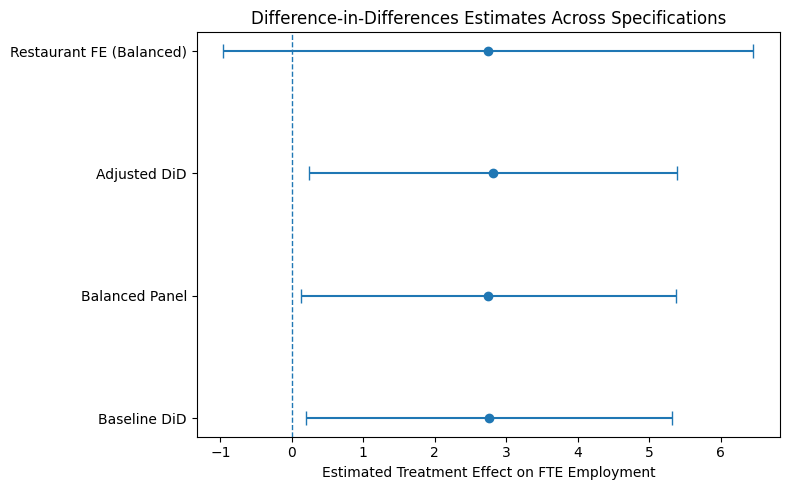

In [55]:
# Coefficient plot across model specifications

plot_results = results_table.copy()

x = plot_results["DiD Estimate"]
y = np.arange(len(plot_results))

lower_error = x - plot_results["95% CI Lower"]
upper_error = plot_results["95% CI Upper"] - x

plt.figure(figsize=(8, 5))

plt.errorbar(
    x,
    y,
    xerr=[lower_error, upper_error],
    fmt="o",
    capsize=5
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.yticks(
    y,
    plot_results["Specification"]
)

plt.xlabel("Estimated Treatment Effect on FTE Employment")
plt.ylabel("")
plt.title("Difference-in-Differences Estimates Across Specifications")

plt.tight_layout()
plt.show()

In [56]:
# Validate the employment-change variable

demp_check = (
    df.groupby("restaurant_id")
      .agg(
          fte_before=("fte", "first"),
          fte_after=("fte", "last"),
          demp=("demp", "first")
      )
)

demp_check["actual_change"] = (
    demp_check["fte_after"] - demp_check["fte_before"]
)

valid = demp_check.dropna()

print(
    "Correlation between demp and calculated FTE change:",
    round(valid["demp"].corr(valid["actual_change"]), 3)
)

print(
    "Maximum absolute difference:",
    (valid["demp"] - valid["actual_change"]).abs().max()
)

Correlation between demp and calculated FTE change: 1.0
Maximum absolute difference: 8.881784197001252e-16


In [57]:
# Heterogeneous Treatment Effects by Restaurant Chain

chain_df = df_balanced.copy()

# Create chain labels
chain_df["chain"] = np.select(
    [
        chain_df["bk"] == 1,
        chain_df["kfc"] == 1,
        chain_df["roys"] == 1,
        chain_df["wendys"] == 1
    ],
    [
        "Burger King",
        "KFC",
        "Roy Rogers",
        "Wendy's"
    ],
    default="Other"
)

# Check sample size by chain and state
chain_counts = (
    chain_df
    .groupby(["chain", "nj"])["restaurant_id"]
    .nunique()
    .unstack(fill_value=0)
    .rename(columns={0: "Pennsylvania", 1: "New Jersey"})
)

print("Number of restaurants by chain and state:")
print(chain_counts)

# Estimate DiD separately for each chain
chain_results = []

for chain in ["Burger King", "KFC", "Roy Rogers", "Wendy's"]:

    temp = chain_df[chain_df["chain"] == chain].copy()

    model = smf.ols(
        "fte ~ nj + d + nj:d",
        data=temp
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": temp["restaurant_id"]}
    )

    ci = model.conf_int().loc["nj:d"]

    chain_results.append({
        "Chain": chain,
        "DiD Estimate": model.params["nj:d"],
        "Clustered SE": model.bse["nj:d"],
        "p-value": model.pvalues["nj:d"],
        "95% CI Lower": ci.iloc[0],
        "95% CI Upper": ci.iloc[1],
        "Restaurants": temp["restaurant_id"].nunique()
    })

chain_results = pd.DataFrame(chain_results)

chain_results.round(3)

Number of restaurants by chain and state:
nj           Pennsylvania  New Jersey
chain                                
Burger King            33         126
KFC                    12          67
Roy Rogers             17          77
Wendy's                13          39


,Chain,DiD Estimate,Clustered SE,p-value,95% CI Lower,95% CI Upper,Restaurants
0,Burger King,4.390,2.533,0.083,-0.574,9.354,159
1,KFC,-1.594,1.065,0.135,-3.682,0.494,79
2,Roy Rogers,2.488,2.138,0.245,-1.703,6.679,94
3,Wendy's,3.417,3.149,0.278,-2.756,9.589,52


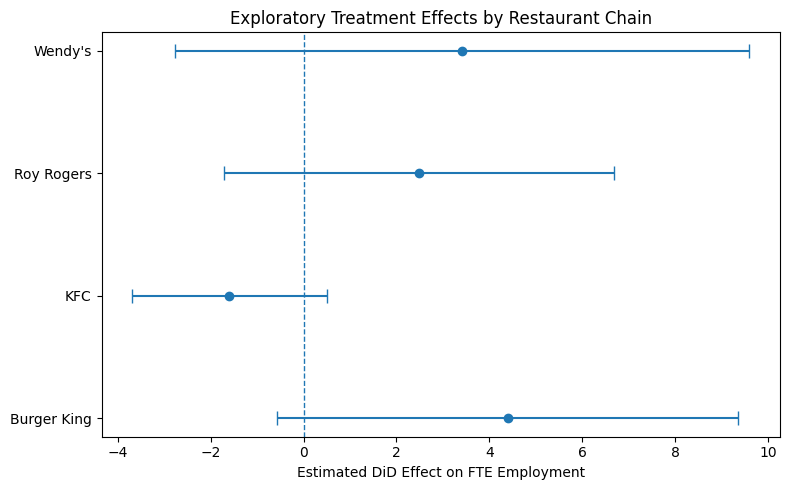

In [58]:
# Exploratory heterogeneous treatment effects by restaurant chain

x = chain_results["DiD Estimate"]
y = np.arange(len(chain_results))

lower_error = x - chain_results["95% CI Lower"]
upper_error = chain_results["95% CI Upper"] - x

plt.figure(figsize=(8, 5))

plt.errorbar(
    x,
    y,
    xerr=[lower_error, upper_error],
    fmt="o",
    capsize=5
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.yticks(
    y,
    chain_results["Chain"]
)

plt.xlabel("Estimated DiD Effect on FTE Employment")
plt.ylabel("")
plt.title("Exploratory Treatment Effects by Restaurant Chain")

plt.tight_layout()
plt.show()

## Results and Interpretation

The baseline Difference-in-Differences estimate is approximately **2.75 full-time-equivalent (FTE) employees**. In the estimation sample, average employment in Pennsylvania declined after the policy period, while average employment in New Jersey increased slightly. The resulting relative change is positive.

Using standard errors clustered at the restaurant level, the baseline estimate is **2.754 FTE** (SE = 1.307, p = 0.035; 95% CI: [0.193, 5.315]).

The result is stable across several alternative specifications:

- **Balanced-panel DiD:** 2.750 FTE (p = 0.040)
- **Adjusted DiD with restaurant-chain and regional controls:** 2.813 FTE (p = 0.033)
- **First-difference specification:** 2.750 FTE (p = 0.040)
- **Restaurant fixed-effects specification:** 2.750 FTE (p = 0.146)

The point estimates are remarkably similar across specifications, remaining close to 2.75–2.81 FTE employees. However, statistical significance is sensitive to the specification: the restaurant fixed-effects model produces a substantially wider confidence interval and is not statistically significant at conventional levels.

Overall, the estimates provide **no evidence that New Jersey's 1992 minimum-wage increase reduced employment relative to Pennsylvania** in this sample. Several specifications instead produce a positive and statistically significant relative employment effect. Because the fixed-effects estimate is less precise, however, the evidence should not be interpreted as establishing a uniformly significant positive employment effect across all specifications.

### Exploratory Heterogeneity

Chain-specific estimates vary considerably. Burger King, Roy Rogers, and Wendy's have positive point estimates, while KFC has a negative point estimate. However, the 95% confidence interval for every chain-specific estimate includes zero.

These results therefore suggest possible heterogeneity across restaurant chains, but the subgroup estimates are imprecise and should be interpreted as exploratory rather than as evidence of systematic differences in treatment effects.

## Identification and Limitations

The Difference-in-Differences design compares the change in fast-food employment in New Jersey before and after the minimum-wage increase with the contemporaneous change in eastern Pennsylvania, where the minimum wage did not change.

A causal interpretation relies on the **parallel-trends assumption**: in the absence of the policy change, employment in New Jersey and Pennsylvania would have followed similar trends.

An important limitation of this dataset is that it contains only one pre-treatment and one post-treatment survey wave. As a result, pre-treatment trends cannot be directly examined or formally tested. The identifying assumption must therefore be justified by the research design and institutional setting rather than demonstrated empirically from multiple pre-policy periods.

Additional limitations include:

- Missing employment observations reduce the usable sample and motivate the balanced-panel robustness analysis.
- The analysis focuses on fast-food restaurants in New Jersey and eastern Pennsylvania, so the results may not generalize to other industries, locations, or minimum-wage changes.
- Chain-level heterogeneous-treatment estimates rely on relatively small Pennsylvania comparison samples and are therefore imprecise.
- Other contemporaneous economic changes could bias the estimates if they affected New Jersey and Pennsylvania differently around the same period.
- Statistical significance varies across specifications, particularly when restaurant fixed effects and clustered inference are combined.

These limitations mean that the estimates should be interpreted as evidence from this specific quasi-experimental setting rather than as a universal estimate of the employment effect of minimum-wage policy.

## Conclusion

This project applies a Difference-in-Differences framework to study New Jersey's 1992 minimum-wage increase using fast-food restaurant employment data from New Jersey and eastern Pennsylvania.

Across the baseline, balanced-panel, covariate-adjusted, and first-difference specifications, the estimated relative employment effect is consistently around **+2.75 to +2.81 FTE employees per restaurant**. The restaurant fixed-effects specification produces a nearly identical point estimate but substantially greater statistical uncertainty.

Taken together, the results do not support the prediction that the minimum-wage increase caused a relative decline in fast-food employment in New Jersey during the study period. At the same time, sensitivity in statistical precision and the limitations of the two-period research design warrant caution in interpreting the positive point estimates.

More broadly, the analysis illustrates how quasi-experimental methods can be used to move beyond simple correlations and estimate policy effects using observational data.